In [1]:
import rasterio
import numpy as np

def reclassify_chm(input_file, output_file):
    """
    Reclasifica Canopy Height Model según rangos especificados
    """
    with rasterio.open(input_file) as src:
        # Leer el array
        chm = src.read(1)
        
        # Crear array de salida
        reclassified = np.zeros_like(chm, dtype=np.int16)
        
        # Aplicar reclasificación
        reclassified[chm <= 0.1] = 0
        reclassified[(chm > 0.1) & (chm <= 0.3)] = 1
        reclassified[(chm > 0.3) & (chm <= 2)] = 2
        reclassified[chm > 2] = 3
        
        # Manejar NoData
        if src.nodata is not None:
            reclassified[chm == src.nodata] = -9999
        
        # Copiar metadatos y actualizar
        meta = src.meta.copy()
        meta.update({
            'dtype': 'int16',
            'nodata': -9999
        })
        
        # Guardar
        with rasterio.open(output_file, 'w', **meta) as dst:
            dst.write(reclassified, 1)

In [6]:
## 0 NoDatas handling

import rasterio
import numpy as np

def reclassify_chm_sin_nodata(input_file, output_file):
    with rasterio.open(input_file) as src:
        chm = src.read(1, masked=False)
        
        reclassified = np.zeros(chm.shape, dtype=np.int16)
        
        # Todo lo que sea NoData original o <= 0.1 va a clase 0
        mask_valid = chm != src.nodata if src.nodata else np.ones_like(chm, dtype=bool)
        
        reclassified[(chm > 0.1) & (chm <= 0.3) & mask_valid] = 1
        reclassified[(chm > 0.3) & (chm <= 2) & mask_valid] = 2
        reclassified[(chm > 2) & mask_valid] = 3
        # El resto (incluyendo NoData) queda en 0
        
        meta = src.meta.copy()
        meta.update({'dtype': 'int16', 'nodata': None})
        
        with rasterio.open(output_file, 'w', **meta) as dst:
            dst.write(reclassified, 1)

In [8]:
ch2014 = '/media/diego/Datos4/EBD/cartografia/las/1Cobertura/Mod_CobVeg_PNOA_2014/canopy_height_2014.tif'
ch2014_reclass = '/media/diego/Datos4/EBD/cartografia/las/1Cobertura/Mod_CobVeg_PNOA_2014/canopy_height_2014_reclass__.tif'

ch2020 = '/media/diego/Datos4/EBD/cartografia/las/2Cobertura/ModVeg_lidar/canopy_height_2020.tif'
ch2020_reclass = '/media/diego/Datos4/EBD/cartografia/las/2Cobertura/ModVeg_lidar/canopy_height_2020_reclass__.tif'

# Usar la función
reclassify_chm_sin_nodata(ch2014, ch2014_reclass)
#reclassify_chm('chm_input2.tif', 'chm_reclassified2.tif')

## Lacoon Stats 

In [1]:
import geopandas as gpd
import rasterio
from rasterstats import zonal_stats
import pandas as pd
import numpy as np

def calcular_superficie_por_clase(raster_file, lagunas_shp, fecha):
    """
    Calcula superficie (en m²) de cada clase CHM en cada laguna
    """
    # Leer lagunas
    lagunas = gpd.read_file(lagunas_shp)
    
    # Obtener resolución del pixel
    with rasterio.open(raster_file) as src:
        pixel_area = abs(src.transform[0] * src.transform[4])  # m² por pixel
    
    resultados = []
    
    for idx, laguna in lagunas.iterrows():
        # Calcular histograma de valores dentro de cada laguna
        stats = zonal_stats(
            laguna.geometry,
            raster_file,
            categorical=True,
            nodata=-9999,
            geojson_out=False
        )
        
        # Extraer conteos por clase
        conteos = stats[0] if stats else {}
        
        # Calcular superficies
        superficie_clase_0 = conteos.get(0, 0) * pixel_area
        superficie_clase_1 = conteos.get(1, 0) * pixel_area
        superficie_clase_2 = conteos.get(2, 0) * pixel_area
        superficie_clase_3 = conteos.get(3, 0) * pixel_area
        
        # Si querías incluir NoData en clase 0:
        # superficie_clase_0 += conteos.get(-9999, 0) * pixel_area
        
        resultados.append({
            'laguna_id': laguna['FORMACION'],
            'laguna_nombre': laguna.get('NOMBRE', laguna['FORMACION']),  # usa NOMBRE si existe, si no usa FORMACION
            'fecha': fecha,
            'superficie_clase_0_m2': superficie_clase_0,
            'superficie_clase_1_m2': superficie_clase_1,
            'superficie_clase_2_m2': superficie_clase_2,
            'superficie_clase_3_m2': superficie_clase_3,
            'superficie_total_m2': superficie_clase_0 + superficie_clase_1 + 
                                   superficie_clase_2 + superficie_clase_3
        })
    
    return pd.DataFrame(resultados)

In [13]:
## Calculamos (h29)

labordette = '/media/diego/Datos4/EBD/cartografia/las/inventario_labordette_last_29.shp'
ch14 = '/media/diego/Datos4/EBD/cartografia/las/1Cobertura/Mod_CobVeg_PNOA_2014/canopy_height_2014_reclass__.tif'
ch20 = '/media/diego/Datos4/EBD/cartografia/las/2Cobertura/ModVeg_lidar/canopy_height_2020_reclass__.tif'
ch24 = '/media/diego/Datos4/EBD/cartografia/las/mosaicos/Canopy_Height_2024.tif'

# Procesar las 3 fechas
df_2014 = calcular_superficie_por_clase(ch14, labordette, 2014)
df_2020 = calcular_superficie_por_clase(ch20, labordette, 2020)
df_2024 = calcular_superficie_por_clase(ch24, labordette, 2024)

# Combinar todo
df_completo = pd.concat([df_2014, df_2020, df_2024], ignore_index=True)

# Calcular porcentajes
for clase in [0, 1, 2, 3]:
    df_completo[f'porcentaje_clase_{clase}'] = (
        df_completo[f'superficie_clase_{clase}_m2'] / 
        df_completo['superficie_total_m2'] * 100
    )

# Guardar resultados
df_completo.to_csv('analisis_matorrizacion_lagunas.csv', index=False)
df_completo.to_excel('analisis_matorrizacion_lagunas.xlsx', index=False)

print(df_completo)

            laguna_id             laguna_nombre  fecha  superficie_clase_0_m2  \
0       FORMACIÓN Nº1                EL LUCIO I   2014            5756.250000   
1       FORMACIÓN Nº2               EL LUCIO II   2014            2718.750000   
2       FORMACIÓN Nº3       LLANOS DE VELÁZQUEZ   2014           12762.500000   
3       FORMACIÓN Nº4                      None   2014            2381.250000   
4       FORMACIÓN Nº5                      None   2014            2693.750000   
...               ...                       ...    ...                    ...   
1768  FORMACIÓN Nº595                      None   2024             180.314683   
1769  FORMACIÓN Nº596   LAGUNA DE LA HIGUERUELA   2024            1887.359733   
1770  FORMACIÓN Nº597           LOS CHARQUILLOS   2024            7248.253967   
1771  FORMACIÓN Nº598  LAGUNA DE JUAN DE DIOS V   2024            1778.378331   
1772  FORMACIÓN Nº637                      None   2024            9592.344848   

      superficie_clase_1_m2

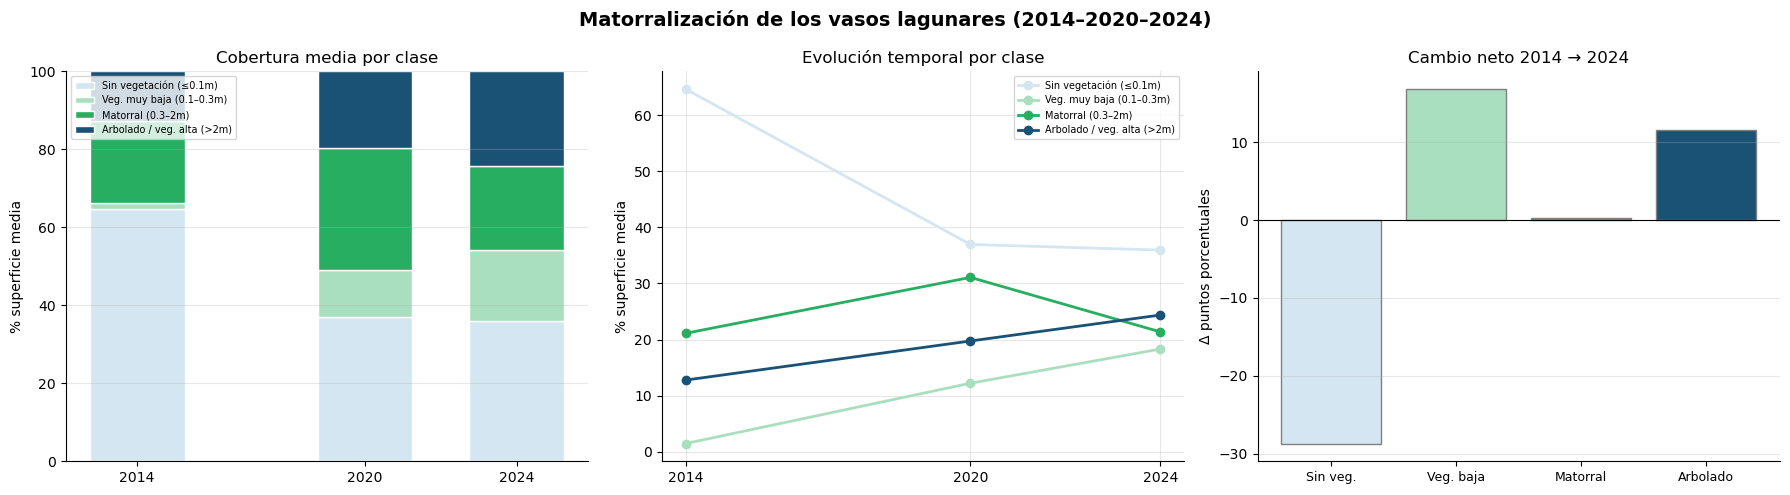

In [9]:
import matplotlib.pyplot as plt
import numpy as np

COLORES = {
    0: "#d4e6f1",
    1: "#a9dfbf",
    2: "#27ae60",
    3: "#1a5276",
}
ETIQUETAS = {
    0: "Sin vegetación (≤0.1m)",
    1: "Veg. muy baja (0.1–0.3m)",
    2: "Matorral (0.3–2m)",
    3: "Arbolado / veg. alta (>2m)",
}
ETIQUETAS_CORTAS = {
    0: "Sin veg.",
    1: "Veg. baja",
    2: "Matorral",
    3: "Arbolado",
}
AÑOS = [2014, 2020, 2024]

# Media por año de cada clase
resumen_pct = df_completo.groupby("fecha")[[f"porcentaje_clase_{c}" for c in range(4)]].mean()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Matorralización de los vasos lagunares (2014–2020–2024)",
             fontsize=14, fontweight="bold")

# ── 1. Stacked bar ──────────────────────────────────────────────────────────
ax = axes[0]
bottom = np.zeros(3)
for c in range(4):
    vals = [resumen_pct.loc[a, f"porcentaje_clase_{c}"] for a in AÑOS]
    ax.bar(AÑOS, vals, bottom=bottom, color=COLORES[c], label=ETIQUETAS[c],
           width=2.5, edgecolor="white")
    bottom += np.array(vals)
ax.set_title("Cobertura media por clase")
ax.set_ylabel("% superficie media")
ax.set_xticks(AÑOS)
ax.set_ylim(0, 100)
ax.legend(fontsize=7, loc="upper left", framealpha=0.8, bbox_to_anchor=(0, 1))
ax.grid(axis="y", alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)

# ── 2. Line plot — evolución de cada clase ──────────────────────────────────
ax = axes[1]
for c in range(4):
    vals = [resumen_pct.loc[a, f"porcentaje_clase_{c}"] for a in AÑOS]
    ax.plot(AÑOS, vals, marker="o", color=COLORES[c], label=ETIQUETAS[c], linewidth=2)
ax.set_title("Evolución temporal por clase")
ax.set_ylabel("% superficie media")
ax.set_xticks(AÑOS)
ax.legend(fontsize=7)
ax.grid(alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)

# ── 3. Cambio neto 2014 → 2024 ──────────────────────────────────────────────
ax = axes[2]
cambios = [resumen_pct.loc[2024, f"porcentaje_clase_{c}"] -
           resumen_pct.loc[2014, f"porcentaje_clase_{c}"] for c in range(4)]
ax.bar([ETIQUETAS_CORTAS[c] for c in range(4)], cambios,
       color=[COLORES[c] for c in range(4)], edgecolor="grey")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Cambio neto 2014 → 2024")
ax.set_ylabel("Δ puntos porcentuales")
ax.tick_params(axis="x", labelsize=9)
ax.grid(axis="y", alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("matorrizacion_lagunas.png", dpi=150, bbox_inches="tight")
plt.show()

In [11]:
df_completo.dtypes

laguna_id                 object
laguna_nombre             object
fecha                      int64
superficie_clase_0_m2    float64
superficie_clase_1_m2    float64
superficie_clase_2_m2    float64
superficie_clase_3_m2    float64
superficie_total_m2      float64
porcentaje_clase_0       float64
porcentaje_clase_1       float64
porcentaje_clase_2       float64
porcentaje_clase_3       float64
dtype: object

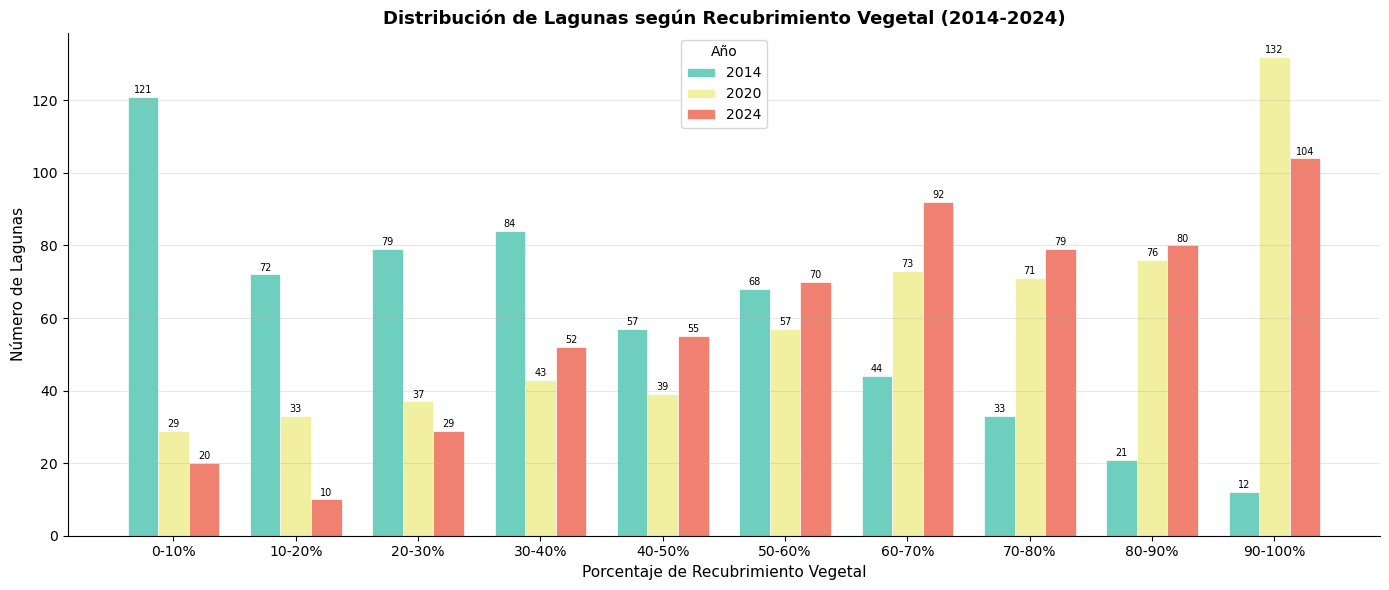

In [12]:
import matplotlib.pyplot as plt
import numpy as np

AÑOS = [2014, 2020, 2024]
COLORES_AÑOS = {2014: "#6ecfbf", 2020: "#f0f0a0", 2024: "#f08070"}

bins = np.arange(0, 110, 10)
etiquetas_bins = [f"{b}-{b+10}%" for b in bins[:-1]]

fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(len(etiquetas_bins))
ancho = 0.25

for i, año in enumerate(AÑOS):
    datos_año = df_completo[df_completo["fecha"] == año]
    pct_veg = datos_año["porcentaje_clase_1"] + datos_año["porcentaje_clase_2"] + datos_año["porcentaje_clase_3"]
    conteos, _ = np.histogram(pct_veg, bins=bins)
    bars = ax.bar(x + i * ancho, conteos, width=ancho,
                  color=COLORES_AÑOS[año], label=str(año),
                  edgecolor="white", linewidth=0.5)
    for bar, val in zip(bars, conteos):
        if val > 0:
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                    str(val), ha="center", va="bottom", fontsize=7)

ax.set_title("Distribución de Lagunas según Recubrimiento Vegetal (2014-2024)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Porcentaje de Recubrimiento Vegetal", fontsize=11)
ax.set_ylabel("Número de Lagunas", fontsize=11)
ax.set_xticks(x + ancho)
ax.set_xticklabels(etiquetas_bins)
ax.legend(title="Año")
ax.grid(axis="y", alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("distribucion_recubrimiento.png", dpi=150, bbox_inches="tight")
plt.show()